# Neal's Funnel

## Test for 2D

In [ ]:
# =========================================================
# PPO-RLFS for Neal's Funnel (annealed σ, proper log F/B)
# =========================================================
import jax
import jax.numpy as jnp
from jax import random, lax, jit, grad
import optax
from flax import linen as nn
from flax.training.train_state import TrainState
import numpy as np
jax.config.update("jax_enable_x64", True)

# =========================================================
# MMD metrics
# =========================================================
def pairwise_sq_dists(X, Y):
    X_norm = jnp.sum(X**2, axis=1, keepdims=True)
    Y_norm = jnp.sum(Y**2, axis=1, keepdims=True).T
    return X_norm + Y_norm - 2.0 * (X @ Y.T)

def rbf_kernel_matrix(X, Y, gamma):
    d2 = pairwise_sq_dists(X, Y)
    return jnp.exp(-gamma * d2)

def median_kernel_width(X, Y):
    Z = jnp.concatenate([X, Y], axis=0)
    d2 = pairwise_sq_dists(Z, Z)
    d2_flat = d2[jnp.triu_indices(d2.shape[0], k=1)]
    d2_flat = d2_flat[jnp.isfinite(d2_flat)]
    if d2_flat.size == 0:
        return 1.0
    med = jnp.median(jnp.sqrt(jnp.clip(d2_flat, 1e-6, 1e6)))
    med = jnp.maximum(med, 1e-3)
    sigma2 = med**2
    return 1.0 / (2.0 * sigma2)

def mmd_unbiased_rbf(X, Y):
    X = X[jnp.isfinite(X).all(axis=1)]
    Y = Y[jnp.isfinite(Y).all(axis=1)]
    n, m = X.shape[0], Y.shape[0]
    if n < 2 or m < 2:
        return jnp.nan
    gamma = median_kernel_width(X, Y)
    Kxx = rbf_kernel_matrix(X, X, gamma)
    Kyy = rbf_kernel_matrix(Y, Y, gamma)
    Kxy = rbf_kernel_matrix(X, Y, gamma)
    sum_Kxx = (jnp.sum(Kxx) - jnp.trace(Kxx)) / (n * (n - 1) + 1e-12)
    sum_Kyy = (jnp.sum(Kyy) - jnp.trace(Kyy)) / (m * (m - 1) + 1e-12)
    sum_Kxy = jnp.sum(Kxy) / (n * m + 1e-12)
    val = sum_Kxx + sum_Kyy - 2.0 * sum_Kxy
    return jnp.nan_to_num(val, nan=0.0, posinf=0.0, neginf=0.0)

# =========================================================
# Target (Neal’s Funnel)
# =========================================================
D = 2
SIGMA2 = 9.0
SIGMA = jnp.sqrt(SIGMA2)

def log_unnormalized_pi(x, sigma2=9.0):
    x1, rest = x[...,0], x[...,1:]
    Dloc = x.shape[-1]
    dminus1 = Dloc-1
    quad = jnp.sum(rest**2, axis=-1)
    cond = -0.5*jnp.exp(-x1)*(quad - dminus1*jnp.exp(x1))
    norm = -0.5*dminus1*x1
    prior = -0.5*(x1**2)/sigma2
    return prior+norm+cond

def sample_funnel(key, n, d=D, sigma2=SIGMA2):
    key1, key2 = random.split(key)
    x1 = random.normal(key1, (n,1))*jnp.sqrt(sigma2)
    s = jnp.exp(x1)
    eps = random.normal(key2, (n,d-1))
    rest = eps*jnp.sqrt(s)
    return jnp.concatenate([x1,rest],axis=1)

# =========================================================
# Env step (variable σ, proper logF/logB)
# =========================================================
EPS = 1e-8

def env_step(key, x_t, mu_t, sigma_act):
    """Forward/Backward pair with given σ."""
    B, D = x_t.shape
    eps = random.normal(key, (B, D))
    x_next = x_t + mu_t + sigma_act * eps

    sigma2_act = sigma_act**2

    # ---- log F ----
    mean_f = x_t + mu_t
    diff_f = (x_next - mean_f) / sigma_act
    logF = -0.5 * jnp.sum(diff_f**2, axis=-1)

    # ---- log B ----
    mean_b = jnp.sqrt(1 - sigma2_act) * x_next
    diff_b = (x_t - mean_b) / sigma_act
    logB = -0.5 * jnp.sum(diff_b**2, axis=-1)

    # ---- reward ----
    r_t = jnp.clip(logB - logF, -20.0, 20.0)
    a_t = x_next - x_t

    diff_p = a_t - mu_t
    logp = -0.5 * jnp.sum(diff_p**2, axis=-1)
    return x_next, a_t, logp, r_t

# =========================================================
# Actor / Critic
# =========================================================
class Actor(nn.Module):
    D: int
    @nn.compact
    def __call__(self, x, t):
        h = nn.tanh(nn.Dense(128, use_bias=True,
                             bias_init=nn.initializers.zeros)(jnp.concatenate([x,t],-1)))
        h = nn.tanh(nn.Dense(128, use_bias=True,
                             bias_init=nn.initializers.zeros)(h))
        out = nn.Dense(self.D, use_bias=True,
                       bias_init=nn.initializers.zeros)(h)
        return out  # ensure no extra bias on channel 0

class Critic(nn.Module):
    hidden:int=256
    @nn.compact
    def __call__(self,x,t_frac):
        h=jnp.concatenate([x,t_frac],axis=-1)
        h=nn.tanh(nn.Dense(self.hidden)(h))
        h=nn.tanh(nn.Dense(self.hidden)(h))
        v=nn.Dense(1)(h)
        return v.squeeze(-1)

class ActorState(TrainState): pass
class CriticState(TrainState): pass

# =========================================================
# Rollout & GAE
# =========================================================
def terminal_reward(x_T, tau=1.): return (1./tau)*log_unnormalized_pi(x_T)

def rollout_episode(rng, actor_params, critic_params,
                    actor_apply, critic_apply,
                    BATCH, D, T, tau, sigma_act):
    rng, key_init = random.split(rng)
    x0 = random.normal(key_init, (BATCH, D))

    def body(carry, t_idx):
        rng, x_t = carry
        t_frac = jnp.ones((BATCH,1)) * (t_idx / T)
        mu_t = actor_apply(actor_params, x_t, t_frac)
        rng, step_key = random.split(rng)
        x_next, a_t, logp, r_t = env_step(step_key, x_t, mu_t, sigma_act)
        v_t = critic_apply(critic_params, x_t, t_frac)
        return (rng, x_next), dict(
            x_t=x_t, a_t=a_t, logprob=logp,
            value=v_t, t_frac=t_frac.squeeze(-1),
            rewards=r_t/tau
        )

    (rng, x_T), traj = lax.scan(body, (rng, x0), jnp.arange(T))
    rew_T = terminal_reward(x_T, tau)
    rewards = jnp.stack(traj["rewards"], axis=0)
    rewards = rewards.at[-1].add(rew_T)
    v_T = critic_apply(critic_params, x_T, jnp.ones((BATCH,1)))
    traj["v_T"] = v_T
    traj["rewards"] = rewards
    traj["x_T"] = x_T
    traj["terminal_bonus"] = rew_T
    return rng, traj

def compute_gae(traj, gamma=1., lam=0.95):
    r, v, v_T = traj["rewards"], traj["value"], traj["v_T"]
    T_len, B = r.shape
    def backward(carry, t_idx):
        gae, next_v = carry
        delta = r[t_idx] + gamma * next_v - v[t_idx]
        gae_t = delta + gamma * lam * gae
        return (gae_t, v[t_idx]), gae_t
    (_, _), adv_rev = lax.scan(backward, (jnp.zeros((B,)), v_T),
                               jnp.arange(T_len-1, -1, -1))
    adv = jnp.flip(adv_rev, axis=0)
    returns = adv + v
    return adv, returns

# =========================================================
# PPO loss
# =========================================================
def gaussian_logprob(mu, a, sigma_act):
    diff = (a - mu) / sigma_act
    quad = -0.5 * jnp.sum(diff**2, axis=-1)
    return quad

def ppo_loss(actor_params, critic_params, batch,
             actor_apply, critic_apply, sigma_act,
             clip_eps=0.2, vf_coef=0.5, entropy_coef=0.01):
    x_t, t_frac, a_t, old_lp, adv_t, ret_t = (
        batch["x_t"], batch["t_frac"], batch["a_t"],
        batch["logprob"], batch["adv"], batch["ret"]
    )
    mu = actor_apply(actor_params, x_t, t_frac[:, None])
    new_lp = gaussian_logprob(mu, a_t, sigma_act)
    ratio = jnp.exp(new_lp - old_lp)
    adv_norm = (adv_t - jnp.mean(adv_t)) / (jnp.std(adv_t) + 1e-8)
    s1 = ratio * adv_norm
    s2 = jnp.clip(ratio, 1 - clip_eps, 1 + clip_eps) * adv_norm
    actor_obj = -jnp.mean(jnp.minimum(s1, s2))
    v_pred = critic_apply(critic_params, x_t, t_frac[:, None])
    v_loss = jnp.mean((ret_t - v_pred)**2)
    dim = a_t.shape[-1]
    entropy = 0.5 * jnp.mean(dim * (1. + jnp.log(2*jnp.pi*(sigma_act**2))))
    total = actor_obj + vf_coef*v_loss - entropy_coef*entropy
    aux = dict(actor_loss=actor_obj, critic_loss=v_loss,
               ratio=jnp.mean(ratio), entropy=entropy)
    return total, aux

# =========================================================
# Training with annealed σ
# =========================================================
def train_funnel_ppo(rng_key=random.PRNGKey(0), D=D, BATCH=2000, T=100,
                     actor_lr=1e-5, critic_lr=1e-6, NITER=1000, MINIBATCH=500,
                     sigma_start=1.0, sigma_end=0.2, decay=0.995):
    actor, critic = Actor(D), Critic()
    rng_key, key_a, key_c, key_ref = random.split(rng_key, 4)
    dummy_x = jnp.zeros((1,D)); dummy_t = jnp.zeros((1,1))
    actor_params = actor.init(key_a, dummy_x, dummy_t)
    critic_params = critic.init(key_c, dummy_x, dummy_t)
    actor_state = ActorState.create(apply_fn=actor.apply, params=actor_params,
                                    tx=optax.adam(actor_lr))
    critic_state = CriticState.create(apply_fn=critic.apply, params=critic_params,
                                      tx=optax.adam(critic_lr))
    ref_samples = sample_funnel(key_ref, 4000, d=D)

    # ---- σ annealing schedule ----
    def sigma_schedule(it, sigma_start=1.0, sigma_end=0.2, decay=0.995):
        # exponential decay
        sigma_now = sigma_end + (sigma_start - sigma_end) * (decay ** it)
        return float(sigma_now)

    @jit
    def do_rollout(rng, a_params, c_params, sigma_now):
        rng, traj = rollout_episode(rng, a_params, c_params,
                                    actor.apply, critic.apply,
                                    BATCH, D, T, 1.0, sigma_now)
        adv, ret = compute_gae(traj)
        batch = dict(
            x_t=traj["x_t"].reshape(T*BATCH, D),
            a_t=traj["a_t"].reshape(T*BATCH, D),
            t_frac=traj["t_frac"].reshape(T*BATCH),
            logprob=traj["logprob"].reshape(T*BATCH),
            adv=adv.reshape(T*BATCH),
            ret=ret.reshape(T*BATCH)
        )
        return rng, batch, traj["x_T"], traj["terminal_bonus"]

    @jit
    def ppo_update(a_state, c_state, batch, sigma_now):
        def l_actor(p):
            l, aux = ppo_loss(p, c_state.params, batch,
                              a_state.apply_fn, c_state.apply_fn, sigma_now)
            return l, aux
        def l_critic(p):
            _, aux = ppo_loss(a_state.params, p, batch,
                              a_state.apply_fn, c_state.apply_fn, sigma_now)
            return aux["critic_loss"], aux
        a_grads, a_aux = jax.grad(l_actor, has_aux=True)(a_state.params)
        c_grads, c_aux = jax.grad(l_critic, has_aux=True)(c_state.params)
        a_state = a_state.apply_gradients(grads=a_grads)
        c_state = c_state.apply_gradients(grads=c_grads)
        aux = {**a_aux, **c_aux}
        return a_state, c_state, aux

    for it in range(1, NITER + 1):
        sigma_now = sigma_schedule(it)
        rng_key, batch, x_T, logpi_T = do_rollout(rng_key, actor_state.params, critic_state.params, sigma_now)
        N = batch["x_t"].shape[0]
        idx = jnp.arange(N)
        for start in range(0, N, MINIBATCH):
            mb_idx = idx[start:start+MINIBATCH]
            mb = {k: v[mb_idx] for k, v in batch.items()}
            actor_state, critic_state, aux = ppo_update(actor_state, critic_state, mb, sigma_now)

        if it % 100 == 0 or it == 1 or it == 2 or it ==3  :
            print(f"[{it:04d}] σ={sigma_now:.3f} | actor={aux['actor_loss']:.3f} "
                  f"critic={aux['critic_loss']:.3f} ent={aux['entropy']:.3f}")
            model_eval = x_T[:2000]
            ref_eval   = ref_samples[:2000]
            mmd2_val = float(mmd_unbiased_rbf(model_eval, ref_eval))
            x1_mean = float(jnp.mean(model_eval[:, 0]))
            rest_var_mean = float(jnp.mean(jnp.var(model_eval[:, 1:], axis=0)))
            print(f"   ↳ MMD²={mmd2_val:.4e} | E[x1]={x1_mean:.3f} | mean Var(rest)={rest_var_mean:.3f}")
            xq1, xq2, xq3 = jnp.percentile(model_eval[:, 0], jnp.array([25, 50, 75]))
            print(f"   ↳ x1 percentile: {xq1:.1f}, {xq2:.1f}, {xq3:.1f}")
            below_mask = model_eval[:, 0] < 0
            above_mask = model_eval[:, 0] >= 0
            if jnp.any(below_mask) and jnp.any(above_mask):
                var_below = jnp.mean(jnp.var(model_eval[below_mask][:, 1:], axis=0))
                var_above = jnp.mean(jnp.var(model_eval[above_mask][:, 1:], axis=0))
                print(f"   ↳ Var(rest | x1<0)={float(var_below):.3f} | Var(rest | x1>0)={float(var_above):.3f}\n")
            else:
                print("   ↳ not enough samples on one side of x1=0 to compute conditional variances.")

    return actor_state, critic_state

if __name__ == "__main__":
    actor_state, crtiic_state = train_funnel_ppo(BATCH=2000, T=50,
                     actor_lr=1e-6, critic_lr=1e-6,
                     NITER=1000, MINIBATCH=10000, sigma_start=0.9,
                     sigma_end=0.3, decay=0.999)


[0001] σ=0.899 | actor=0.002 ent=2.626 | ratio=0.839 | baseline=-293011540578983.312
   ↳ MMD²=3.3661e-01 | E[x1]=1.754 | mean Var(rest)=619.607
   ↳ x1 percentile: -13.6, 2.3, 17.8
   ↳ Var(rest | x1<0)=314.977 | Var(rest | x1>0)=334.612

[0002] σ=0.899 | actor=0.001 ent=2.624 | ratio=0.840 | baseline=-386763986151764.938
   ↳ MMD²=3.3498e-01 | E[x1]=2.434 | mean Var(rest)=615.292
   ↳ x1 percentile: -12.4, 2.9, 18.0
   ↳ Var(rest | x1<0)=305.334 | Var(rest | x1>0)=315.860

[0003] σ=0.898 | actor=0.002 ent=2.623 | ratio=0.840 | baseline=-403417929847270.688
   ↳ MMD²=3.3415e-01 | E[x1]=2.476 | mean Var(rest)=619.612
   ↳ x1 percentile: -12.5, 2.5, 18.4
   ↳ Var(rest | x1<0)=328.425 | Var(rest | x1>0)=306.967



KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

def generate_samples(rng_key, actor_state, D=5, T=50, N=2000, x0_scale=3.0):
    """Generate final samples x_T from trained PPO-RLFS actor."""
    actor_apply = actor_state.apply_fn
    params = actor_state.params
    sigma = float(actor_state.sigma)

    rng_key, key_init = random.split(rng_key)
    x0 = x0_scale * random.normal(key_init, (N, D))

    def body(carry, t_idx):
        rng, x_t = carry
        rng, step_key = random.split(rng)
        t_frac = jnp.ones((N, 1)) * (t_idx / T)
        mu_t = actor_apply(params, x_t, t_frac)
        eps = random.normal(step_key, (N, D))
        x_next = x_t + mu_t + sigma * eps
        return (rng, x_next), x_next

    (_, x_T_seq) = lax.scan(body, (rng_key, x0), jnp.arange(T))
    x_T = x_T_seq[-1]
    return x_T

x_T = generate_samples(random.PRNGKey(0), actor_state, D=D, T=50, N=8000)

def sample_funnel_2d(key, n=10000, sigma2=9.0):
    key1, key2 = jax.random.split(key)
    x1 = jax.random.normal(key1, (n,)) * jnp.sqrt(sigma2)
    x2 = jax.random.normal(key2, (n,)) * jnp.exp(0.5 * x1)
    return jnp.stack([x1, x2], axis=1)

samples_ref = sample_funnel_2d(random.PRNGKey(0), n=80000)
plt.figure(figsize=(10,5))

# Determine global axis limits
x1_all = np.concatenate([np.array(samples_ref[:,0]), np.array(x_T[:,0])])
x2_all = np.concatenate([np.array(samples_ref[:,1]), np.array(x_T[:,1])])
x1_min, x1_max = np.min(x1_all), np.max(x1_all)
x2_min, x2_max = np.min(x2_all), np.max(x2_all)

# left plot
plt.subplot(1,2,1)
plt.scatter(np.array(samples_ref[:,0]), np.array(samples_ref[:,1]),
            s=2, alpha=0.3, label="True Funnel")
plt.title("Ground Truth Funnel")
plt.xlabel("x₁"); plt.ylabel("x₂")
plt.xlim(x1_min, x1_max)
plt.ylim(x2_min, x2_max)

# right plot
plt.subplot(1,2,2)
plt.scatter(np.array(x_T[:,0]), np.array(x_T[:,1]),
            s=2, alpha=0.3, label="RLFS Samples", color='orange')
plt.title("RLFS-PPO Samples")
plt.xlabel("x₁"); plt.ylabel("x₂")
plt.xlim(x1_min, x1_max)
plt.ylim(x2_min, x2_max)

plt.tight_layout()
plt.show()


AttributeError: 'ActorState' object has no attribute 'sigma'

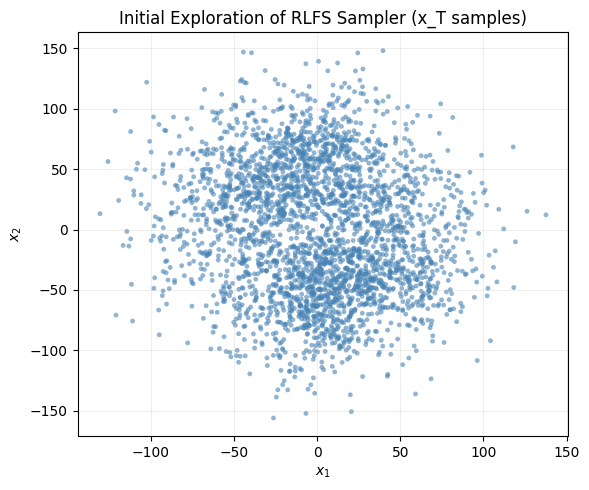

In [ ]:
import matplotlib.pyplot as plt

if __name__ == "__main__":
    # --- initialize ---
    rng_key = random.PRNGKey(0)
    D = 2
    BATCH = 3000
    T = 50
    sigma_now = 5  # initial exploration width

    actor = Actor(D)
    critic = Critic()
    rng_key, key_a, key_c = random.split(rng_key, 3)
    dummy_x = jnp.zeros((1, D))
    dummy_t = jnp.zeros((1, 1))
    actor_params = actor.init(key_a, dummy_x, dummy_t)
    critic_params = critic.init(key_c, dummy_x, dummy_t)

    # --- single rollout with untrained actor ---
    rng_key, traj = rollout_episode(
        rng_key,
        actor_params,
        critic_params,
        actor.apply,
        critic.apply,
        BATCH,
        D,
        T,
        1.0,
        sigma_now
    )

    x_T = np.array(traj["x_T"])  # convert to numpy for plotting

    # --- plot ---
    plt.figure(figsize=(6, 5))
    plt.scatter(x_T[:, 0], x_T[:, 1], s=12, alpha=0.6, color="steelblue", edgecolor="none")
    plt.title("Initial Exploration of RLFS Sampler (x_T samples)")
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
